# EEG Eye-State · Sample-Level MLP + Optuna

This notebook classifies **each individual EEG sample** (no windowing, no feature engineering).  
Each observation is a vector of the 14 raw channel amplitudes — the MLP learns to map that  
directly to *eyes open / eyes closed*.

### What changed vs. the windowed version

| | Windowed notebook | This notebook |
|---|---|---|
| Input | 70 engineered features (band power + CV) | 14 raw channel values |
| Granularity | 1 prediction per 0.5 s window | **1 prediction per sample (~7.8 ms)** |
| Label | open if *any* sample in window was open | raw `eyeDetection` label |
| Feature step | Welch PSD + CV extraction | none — raw values go straight in |

> **Artifact note:** apply `remove_artifacts_interpolate` before training  
> if your data contains high-amplitude spikes (see companion cleaning notebook).


## 1 · Imports & Setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import logging
import os

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from mne.filter import filter_data
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from scipy.io import arff
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib

matplotlib.use("Agg")  # remove this line if running interactively
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}  |  Optuna: {optuna.__version__}")

Device : cpu
PyTorch: 2.11.0  |  Optuna: 4.8.0


## 2 · Load Dataset

The dataset is the **UCI EEG Eye State** dataset (Roesler, 2013).  
14 EEG channels @ 128 Hz, 14 980 observations.  
Target: `eyeDetection` — 0 = eyes closed, 1 = eyes open.


In [2]:
## IMPORT DATA
def load_arff(file_path):
    """Loads an ARFF file into a pandas DataFrame.

    Args:
        file_path (str): The path to the ARFF file.

    Returns:
        pd.DataFrame: A pandas DataFrame containing the data from the ARFF file,
        or None if an error occurs.
    """
    if not file_path.lower().endswith(".arff"):
        logging.error(f"Invalid file type: {file_path}. Expected a .arff file.")
        return None

    if not os.path.exists(file_path):
        logging.error(f"File not found: {file_path}")
        return None

    try:
        logging.info("Loading data...")
        data, meta = arff.loadarff(file_path)
        df = pd.DataFrame(data)
        logging.info("Data loaded successfully.")
        return df
    except FileNotFoundError:
        logging.error(f"File not found: {file_path}")
    except Exception as e:
        logging.error(f"Error loading ARFF file: {e}")
    return None

In [3]:
print("Loading dataset …")

#data_path = "/Users/vinicius/.cache/kagglehub/datasets/robikscube/eye-state-classification-eeg-dataset/versions/1"
data_path = "../data/"

#df = load_arff(os.path.join(data_path, "EEG_DATA.arff"))
df = pd.read_csv(f"{data_path}/session_test_2.csv", sep=";")

EEG_COLS = [c for c in df.columns if c != "eyeDetection" and c != "timestamp"]
TARGET = "eyeDetection"

print(f"  Shape : {df.shape}")
print(f"  Channels ({len(EEG_COLS)}): {EEG_COLS}")
print(f"  Class balance:\n{df[TARGET].value_counts()}\n")

Loading dataset …
  Shape : (21318, 18)
  Channels (16): ['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'ch8', 'ch9', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch16']
  Class balance:
eyeDetection
0    13003
1     8315
Name: count, dtype: int64



## 3 · Optional Artifact Removal

High-amplitude spikes (electrode pops, movement) can dominate the raw signal.  
We replace samples beyond quantile thresholds with linearly interpolated values,  
optionally expanding the bad mask by `margin` samples to catch spike edges.

Set `APPLY_CLEANING = False` to skip this step.


In [4]:
APPLY_CLEANING = True  # ← toggle here
Q_UPPER = 0.999
Q_LOWER = 0.001
MARGIN = 5  # extra samples flagged each side of a spike
FS = 128


def remove_artifacts_interpolate(
    df: pd.DataFrame,
    eeg_cols: list,
    q_upper: float = 0.999,
    q_lower: float = 0.001,
    margin: int = 5,
) -> pd.DataFrame:
    """
    Detect artifact samples (outside [q_lower, q_upper] quantiles) per channel,
    expand the bad window by `margin` samples on each side to catch spike edges,
    then linearly interpolate across the gap.
    """
    df_clean = df.copy()
    total_replaced = 0

    for ch in eeg_cols:
        col = df_clean[ch].copy().astype(float)
        upper = col.quantile(q_upper)
        lower = col.quantile(q_lower)

        bad = (col > upper) | (col < lower)

        # expand mask by margin
        bad_exp = bad.copy()
        for s in range(1, margin + 1):
            bad_exp |= bad.shift(s, fill_value=False)
            bad_exp |= bad.shift(-s, fill_value=False)

        col[bad_exp] = np.nan
        df_clean[ch] = col.interpolate(method="linear", limit_direction="both")
        total_replaced += bad_exp.sum()

    print(f"Artifact removal: {total_replaced} sample-channel values replaced.")
    return df_clean


if APPLY_CLEANING:
    df = remove_artifacts_interpolate(df, EEG_COLS, Q_UPPER, Q_LOWER, MARGIN)
else:
    print("Skipping artifact removal.")

df.iloc[:, 1:-1] = filter_data(df.iloc[:, 1:-1].values.T, FS, .1, 60).T

Artifact removal: 1243 sample-channel values replaced.
Setting up band-pass filter from 0.1 - 60 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 60.00 Hz
- Upper transition bandwidth: 4.00 Hz (-6 dB cutoff frequency: 62.00 Hz)
- Filter length: 4225 samples (33.008 s)



## 4 · Build Sample-Level Dataset

No windowing, no feature extraction — each row of the dataframe becomes  
one training example with **14 raw channel values** as input.


In [5]:
X_np = df[EEG_COLS].values.astype(np.float32)  # (14980, 14)
y_np = df[TARGET].values.astype(int)  # (14980,)

print(f"X : {X_np.shape}  (n_samples × n_channels)")
print(f"y : {y_np.shape}  classes={np.bincount(y_np)}  (closed / open)")

X : (21318, 16)  (n_samples × n_channels)
y : (21318,)  classes=[13003  8315]  (closed / open)


In [6]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

transformer = PCA(n_components=14,
        random_state=0,)

X_np = transformer.fit_transform(X_np)
X_np.shape

(21318, 14)

## 5 · Preprocessing — StandardScaler

EEG channels have similar but not identical ranges (~4000 µV mean in this dataset).  
StandardScaler removes the mean and scales to unit variance per channel,  
which helps gradient-based optimisers converge faster.


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_np).astype(np.float32)

X_torch = torch.tensor(X_scaled)
y_torch = torch.tensor(y_np, dtype=torch.float32)

print(f"X_torch : {X_torch.shape}  dtype={X_torch.dtype}")
print(f"y_torch : {y_torch.shape}  dtype={y_torch.dtype}")
print(f"\nPer-channel mean after scaling (should be ~0):")
print(np.round(X_scaled.mean(axis=0), 4))

X_torch : torch.Size([21318, 14])  dtype=torch.float32
y_torch : torch.Size([21318])  dtype=torch.float32

Per-channel mean after scaling (should be ~0):
[-0.  0. -0.  0.  0. -0. -0.  0. -0.  0. -0.  0. -0. -0.]


## 6 · Variable-Depth MLP

Same flexible architecture as the windowed version.  
The only difference is `in_dim = 14` (raw channels) instead of 70.

Each hidden layer optionally has:
- **Batch Normalisation** — stabilises activations across the mini-batch  
- **Dropout** — randomly zeros activations during training to prevent overfitting


In [8]:
class MLP(nn.Module):
    """
    Flexible MLP with configurable depth, width, dropout, BN, and activation.

    Parameters
    ----------
    in_dim       : input dimensionality (14 for raw EEG channels)
    layer_sizes  : list of hidden-layer widths, e.g. [128, 64]
    dropout_rate : dropout probability after each hidden activation
    activation   : 'relu' | 'leaky_relu' | 'elu' | 'gelu'
    use_bn       : insert BatchNorm1d before each activation
    """

    ACTIVATIONS = {
        "relu": nn.ReLU,
        "leaky_relu": nn.LeakyReLU,
        "elu": nn.ELU,
        "gelu": nn.GELU,
    }

    def __init__(
        self,
        in_dim: int,
        layer_sizes: list,
        dropout_rate: float,
        activation: str,
        use_bn: bool,
    ):
        super().__init__()
        Act = self.ACTIVATIONS[activation]
        layers = []
        prev = in_dim

        for size in layer_sizes:
            layers.append(nn.Linear(prev, size))
            if use_bn:
                layers.append(nn.BatchNorm1d(size))
            layers.append(Act())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev = size

        layers.append(nn.Linear(prev, 1))  # binary output logit
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(1)


# Quick sanity check with raw input dim = 14
_demo = MLP(14, [64, 32], dropout_rate=0.3, activation="elu", use_bn=True)
print(_demo)
print(f"\nTotal parameters: {sum(p.numel() for p in _demo.parameters()):,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ELU(alpha=1.0)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 3,265


## 7 · Training & Evaluation Helpers

In [9]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()


@torch.no_grad()
def eval_auc(model, X_val: torch.Tensor, y_val: torch.Tensor) -> float:
    model.eval()
    loader = DataLoader(TensorDataset(X_val, y_val), batch_size=512)
    probs = torch.cat(
        [torch.sigmoid(model(xb.to(DEVICE))).cpu() for xb, _ in loader]
    ).numpy()
    return float(roc_auc_score(y_val.numpy(), probs))


def build_optimizer(model, name: str, lr: float, wd: float):
    if name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    else:
        return torch.optim.SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)


def run_fold(
    X_tr,
    y_tr,
    X_va,
    y_va,
    layer_sizes,
    dropout,
    activation,
    use_bn,
    opt_name,
    lr,
    wd,
    batch_size,
    max_epochs=40,
    patience=8,
):
    """Train one fold; return (best_auc, preds, probs, auc_history)."""
    pos_weight = torch.tensor([(y_tr == 0).sum() / max((y_tr == 1).sum(), 1)])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    model = MLP(X_scaled.shape[1], layer_sizes, dropout, activation, use_bn).to(DEVICE)
    optimizer = build_optimizer(model, opt_name, lr, wd)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

    best_auc, best_state, pat_count, history = 0.0, None, 0, []

    for _ in range(max_epochs):
        train_epoch(model, loader, optimizer, criterion)
        auc = eval_auc(model, X_va, y_va)
        history.append(auc)

        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            pat_count = 0
        else:
            pat_count += 1
        if pat_count >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_loader = DataLoader(TensorDataset(X_va, y_va), batch_size=512)
        probs = torch.cat(
            [torch.sigmoid(model(xb.to(DEVICE))).cpu() for xb, _ in val_loader]
        ).numpy()

    return best_auc, (probs >= 0.5).astype(int), probs, history


print("Helpers defined.")

Helpers defined.


## 8 · Optuna Hyperparameter Search

### Search space

| Hyperparameter | Range / Choices |
|---|---|
| `n_layers` | 1 – 6 |
| Hidden widths | 16 – 512 (log-scale); each layer ≤ previous (tapering) |
| `dropout` | 0.0 – 0.6 |
| `activation` | relu, leaky_relu, elu, gelu |
| `use_bn` | True / False |
| `optimizer` | adam, adamw, sgd |
| `lr` | 1e-4 – 1e-2 (log-scale) |
| `weight_decay` | 1e-5 – 1e-2 (log-scale) |
| `batch_size` | 64, 128, 256, 512 |

> Batch sizes are larger than in the windowed version because we have ~15k samples  
> (vs ~230 windows), so bigger batches give stable gradient estimates.


In [10]:
N_TRIALS = 10
INNER_FOLDS = 3
cv_inner = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=42)


def objective(trial: optuna.Trial) -> float:
    # ── architecture ──────────────────────────────────────────────────
    n_layers = trial.suggest_int("n_layers", 1, 6)
    h0 = trial.suggest_int("h0", 16, 512, log=True)
    sizes = [h0]
    for i in range(1, n_layers):
        sizes.append(trial.suggest_int(f"h{i}", 16, sizes[-1]))

    dropout = trial.suggest_float("dropout", 0.0, 0.6)
    activation = trial.suggest_categorical(
        "activation", ["relu", "leaky_relu", "elu", "gelu"]
    )
    use_bn = trial.suggest_categorical("use_bn", [True, False])

    # ── optimiser ─────────────────────────────────────────────────────
    opt_name = trial.suggest_categorical("optimizer", ["adam", "adamw", "sgd"])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])

    # ── inner CV ──────────────────────────────────────────────────────
    fold_aucs = []
    for fold, (tr_idx, va_idx) in enumerate(cv_inner.split(X_scaled, y_np)):
        auc, _, _, _ = run_fold(
            X_torch[tr_idx],
            y_torch[tr_idx],
            X_torch[va_idx],
            y_torch[va_idx],
            sizes,
            dropout,
            activation,
            use_bn,
            opt_name,
            lr,
            wd,
            batch_size,
        )
        fold_aucs.append(auc)
        trial.report(np.mean(fold_aucs), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_aucs))


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=8, n_warmup_steps=0),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest trial : #{study.best_trial.number}")
print(f"Best AUC   : {study.best_value:.4f}")
print("\nBest params:")
for k, v in study.best_params.items():
    print(f"  {k:20s}: {v}")

Best trial: 8. Best value: 0.999286: 100%|█| 10/10 [03:30<00:00, 21.10s/


Best trial : #8
Best AUC   : 0.9993

Best params:
  n_layers            : 3
  h0                  : 142
  h1                  : 96
  h2                  : 59
  dropout             : 0.05417386203264498
  activation          : relu
  use_bn              : False
  optimizer           : adamw
  lr                  : 0.0019513967655934471
  weight_decay        : 3.3350264835699565e-05
  batch_size          : 256


## 9 · Extract Best Configuration

In [11]:
p = study.best_params
n_layers = p["n_layers"]
layer_sizes = [p["h0"]] + [p[f"h{i}"] for i in range(1, n_layers)]
dropout = p["dropout"]
activation = p["activation"]
use_bn = p["use_bn"]
opt_name = p["optimizer"]
lr = p["lr"]
wd = p["weight_decay"]
batch_size = p["batch_size"]

print("Best architecture")
print(
    f"  Input (14)  →  " + "  →  ".join(str(s) for s in layer_sizes) + "  →  Output (1)"
)
print(f"  Dropout    : {dropout:.3f}")
print(f"  Activation : {activation}")
print(f"  Batch Norm : {use_bn}")
print(f"  Optimizer  : {opt_name}  (lr={lr:.2e}, wd={wd:.2e})")
print(f"  Batch size : {batch_size}")

Best architecture
  Input (14)  →  142  →  96  →  59  →  Output (1)
  Dropout    : 0.054
  Activation : relu
  Batch Norm : False
  Optimizer  : adamw  (lr=1.95e-03, wd=3.34e-05)
  Batch size : 256


## 10 · Final Evaluation — 5-Fold Cross-Validation

Re-train the best config with **5-fold stratified CV**.  
Because each sample is predicted independently, we also reconstruct a  
**full time-series of predictions** to visualise how well the model  
tracks the true eye-state transitions over time.


In [12]:
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_aucs = []
all_preds = np.zeros(len(y_np), dtype=int)
all_probs = np.zeros(len(y_np), dtype=np.float32)
train_hists = []

for fold, (tr_idx, va_idx) in enumerate(cv_outer.split(X_scaled, y_np)):
    auc, preds, probs, hist = run_fold(
        X_torch[tr_idx],
        y_torch[tr_idx],
        X_torch[va_idx],
        y_torch[va_idx],
        layer_sizes,
        dropout,
        activation,
        use_bn,
        opt_name,
        lr,
        wd,
        batch_size,
        max_epochs=60,
        patience=10,
    )
    final_aucs.append(auc)
    all_preds[va_idx] = preds
    all_probs[va_idx] = probs
    train_hists.append(hist)
    print(f"Fold {fold+1}  AUC={auc:.4f}  epochs={len(hist)}")

print(f"\nMean AUC : {np.mean(final_aucs):.4f} ± {np.std(final_aucs):.4f}")
print(f"Accuracy : {(all_preds == y_np).mean():.4f}")
print()
print(classification_report(y_np, all_preds, target_names=["Closed", "Open"]))

Fold 1  AUC=0.9997  epochs=34
Fold 2  AUC=0.9991  epochs=27
Fold 3  AUC=0.9994  epochs=41
Fold 4  AUC=0.9996  epochs=42
Fold 5  AUC=0.9995  epochs=36

Mean AUC : 0.9995 ± 0.0002
Accuracy : 0.9906

              precision    recall  f1-score   support

      Closed       1.00      0.99      0.99     13003
        Open       0.98      0.99      0.99      8315

    accuracy                           0.99     21318
   macro avg       0.99      0.99      0.99     21318
weighted avg       0.99      0.99      0.99     21318



## 11 · Plot A — Optuna Optimisation History

In [13]:
DARK = "#0a0e17"
CARD = "#111827"
EDGE = "#1f2937"
TEAL = "#00e5cc"
CORAL = "#ff4f5e"
GOLD = "#ffc947"
LIME = "#a8ff3e"
WHITE = "#f0f4ff"
GRAY = "#6b7280"

trials_df = study.trials_dataframe(attrs=("number", "value", "params", "state"))
comp = trials_df[trials_df["state"] == "COMPLETE"].sort_values("number")
vals = comp["value"].values
nums = comp["number"].values
best_sf = np.maximum.accumulate(vals)

fig, ax = plt.subplots(figsize=(12, 4), facecolor=DARK)
ax.set_facecolor(CARD)
for s in ax.spines.values():
    s.set_color(EDGE)

ax.scatter(nums, vals, color=TEAL, alpha=0.5, s=35, zorder=3, label="Trial AUC")
ax.plot(nums, best_sf, color=GOLD, lw=2.5, zorder=4, label="Best so far")
ax.axhline(
    best_sf[-1],
    color=CORAL,
    lw=1.2,
    ls="--",
    label=f"Best = {best_sf[-1]:.4f}",
    alpha=0.8,
)

ax.set_xlabel("Trial", color=WHITE, fontsize=11)
ax.set_ylabel("Validation AUC (3-fold)", color=WHITE, fontsize=11)
ax.set_title(
    "Optuna Optimisation History — TPE Sampler + Median Pruner",
    color=WHITE,
    fontsize=13,
    fontweight="bold",
)
ax.tick_params(colors=WHITE)
ax.yaxis.grid(True, color=EDGE, lw=0.8)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=10)

plt.tight_layout()
plt.savefig("plot_optuna_history.png", dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()

## 12 · Plot B — Best Architecture Diagram

In [14]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK)
ax.set_facecolor(CARD)
ax.axis("off")
for s in ax.spines.values():
    s.set_color(EDGE)
ax.set_title(
    "Best MLP Architecture — Sample-Level (input dim = 14)",
    color=WHITE,
    fontsize=14,
    fontweight="bold",
    pad=15,
)

all_sz = [14] + layer_sizes + [1]
max_n = max(all_sz)
x_pos = np.linspace(0.05, 0.95, len(all_sz))
nc = [TEAL] + [LIME] * n_layers + [CORAL]
act_short = activation[:3].upper()
lbls = (
    ["Input\n(14 ch)"]
    + [f"FC {s}\n{act_short}\ndrop={dropout:.2f}" for s in layer_sizes]
    + ["Output\n(1)\nσ"]
)

for i, (x, sz, col, lbl) in enumerate(zip(x_pos, all_sz, nc, lbls)):
    r = 0.03 + 0.07 * (sz / max_n)
    ax.add_patch(
        mpatches.Circle(
            (x, 0.55), r, color=col, alpha=0.85, transform=ax.transAxes, zorder=3
        )
    )
    ax.text(
        x,
        0.55,
        str(sz),
        ha="center",
        va="center",
        color="black",
        fontsize=8,
        fontweight="bold",
        transform=ax.transAxes,
    )
    ax.text(
        x,
        0.12,
        lbl,
        ha="center",
        va="center",
        color=WHITE,
        fontsize=7.5,
        transform=ax.transAxes,
    )
    if i < len(all_sz) - 1:
        ax.annotate(
            "",
            xy=(x_pos[i + 1] - 0.03, 0.55),
            xytext=(x + r + 0.01, 0.55),
            xycoords="axes fraction",
            textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color=GRAY, lw=1.8),
        )

meta = (
    f"Depth={n_layers}   {opt_name.upper()}   LR={lr:.1e}   "
    f"BN={'Yes' if use_bn else 'No'}   Dropout={dropout:.3f}"
)
ax.text(
    0.5,
    0.93,
    meta,
    ha="center",
    color=GOLD,
    fontsize=10,
    transform=ax.transAxes,
    fontweight="bold",
)

plt.tight_layout()
plt.savefig("plot_architecture.png", dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()

## 13 · Plot C — Predicted vs True Eye-State Over Time

Because we predict **every sample**, we can overlay the model's output  
on the raw time-series and check whether it correctly tracks  
the transitions between open/closed periods.


In [15]:
# Show a representative 5-second excerpt that includes a transition
EXCERPT_START = 8_000
EXCERPT_END = 9_500
t = np.arange(EXCERPT_START, EXCERPT_END)

# Use one channel for the background signal (O1 — occipital, most informative)
ch_idx = EEG_COLS.index("O1") if "O1" in EEG_COLS else 0
signal = X_np[EXCERPT_START:EXCERPT_END, ch_idx]
true_lbl = y_np[EXCERPT_START:EXCERPT_END]
pred_lbl = all_preds[EXCERPT_START:EXCERPT_END]
prob = all_probs[EXCERPT_START:EXCERPT_END]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), facecolor=DARK, sharex=True)
fig.suptitle(
    "Sample-Level Predictions vs Ground Truth",
    color=WHITE,
    fontsize=14,
    fontweight="bold",
)

# Panel 1: raw EEG signal with coloured background
ax = axes[0]
ax.set_facecolor(CARD)
for s in ax.spines.values():
    s.set_color(EDGE)
ax.plot(t, signal, color=TEAL, lw=0.8, alpha=0.9)
for i in range(len(t) - 1):
    colour = "#1a3a2a" if true_lbl[i] == 1 else "#1a1a2a"
    ax.axvspan(t[i], t[i + 1], alpha=0.35, color=colour, linewidth=0)
ax.set_ylabel(f"Channel {EEG_COLS[ch_idx]}", color=WHITE)
ax.tick_params(colors=WHITE)
ax.set_title(
    "Raw EEG  (green bg = eyes open, dark bg = eyes closed)", color=GRAY, fontsize=9
)

# Panel 2: true vs predicted binary labels
ax = axes[1]
ax.set_facecolor(CARD)
for s in ax.spines.values():
    s.set_color(EDGE)
ax.step(t, true_lbl, where="mid", color=LIME, lw=1.5, label="True label", alpha=0.9)
ax.step(
    t,
    pred_lbl,
    where="mid",
    color=CORAL,
    lw=1.5,
    label="Pred label",
    alpha=0.8,
    linestyle="--",
)
ax.set_ylabel("Eye State", color=WHITE)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Closed", "Open"], color=WHITE)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=9)
ax.yaxis.grid(True, color=EDGE)

# Panel 3: predicted probability
ax = axes[2]
ax.set_facecolor(CARD)
for s in ax.spines.values():
    s.set_color(EDGE)
ax.fill_between(t, prob, alpha=0.4, color=GOLD)
ax.plot(t, prob, color=GOLD, lw=1.2)
ax.axhline(0.5, color=WHITE, lw=0.8, ls="--", alpha=0.5, label="threshold=0.5")
ax.set_ylabel("P(eyes open)", color=WHITE)
ax.set_xlabel("Sample index", color=WHITE)
ax.tick_params(colors=WHITE)
ax.set_ylim(0, 1)
ax.yaxis.grid(True, color=EDGE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=9)

plt.tight_layout()
plt.savefig(
    "plot_timeseries_predictions.png", dpi=150, bbox_inches="tight", facecolor=DARK
)
plt.show()

## 14 · Plot D — Per-Fold Training Curves

In [16]:
fold_colors = [TEAL, GOLD, LIME, CORAL, "#aa88ff"]

fig, ax = plt.subplots(figsize=(10, 5), facecolor=DARK)
ax.set_facecolor(CARD)
for s in ax.spines.values():
    s.set_color(EDGE)

for fi, hist in enumerate(train_hists):
    ax.plot(hist, color=fold_colors[fi], lw=2, alpha=0.9, label=f"Fold {fi+1}")

ax.set_xlabel("Epoch", color=WHITE, fontsize=11)
ax.set_ylabel("Validation AUC", color=WHITE, fontsize=11)
ax.set_title(
    "Training Curves — Best Config (5-fold CV)",
    color=WHITE,
    fontsize=13,
    fontweight="bold",
)
ax.tick_params(colors=WHITE)
ax.yaxis.grid(True, color=EDGE, lw=0.8)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=10)

plt.tight_layout()
plt.savefig("plot_training_curves.png", dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()

## 15 · Plot E — Hyperparameter Analysis

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), facecolor=DARK)

for ax, title in zip(
    axes,
    ["Layer Depth Distribution", "Dropout Rate Distribution", "Learning Rate vs AUC"],
):
    ax.set_facecolor(CARD)
    for s in ax.spines.values():
        s.set_color(EDGE)
    ax.tick_params(colors=WHITE)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight="bold")

# Panel 1: layer depth
col_nl = "params_n_layers"
if col_nl in comp.columns:
    nlv = comp[col_nl].dropna().astype(int)
    counts = nlv.value_counts().sort_index()
    bar_c = [GOLD if i == n_layers else TEAL for i in counts.index]
    axes[0].bar(counts.index, counts.values, color=bar_c, alpha=0.9, edgecolor=EDGE)
    axes[0].set_xlabel("# Hidden Layers", color=WHITE, fontsize=10)
    axes[0].set_ylabel("# Trials", color=WHITE, fontsize=10)
    axes[0].yaxis.grid(True, color=EDGE)

# Panel 2: dropout histogram
col_dr = "params_dropout"
if col_dr in comp.columns:
    axes[1].hist(comp[col_dr].dropna(), bins=16, color=LIME, alpha=0.75, edgecolor=EDGE)
    axes[1].axvline(
        dropout, color=CORAL, lw=2.5, ls="--", label=f"Best = {dropout:.3f}"
    )
    axes[1].set_xlabel("Dropout Rate", color=WHITE, fontsize=10)
    axes[1].set_ylabel("Count", color=WHITE, fontsize=10)
    axes[1].yaxis.grid(True, color=EDGE)
    axes[1].legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)

# Panel 3: LR vs AUC scatter
col_lr = "params_lr"
if col_lr in comp.columns:
    sc = axes[2].scatter(
        comp[col_lr].values,
        comp["value"].values,
        c=comp["value"].values,
        cmap="plasma",
        s=50,
        alpha=0.85,
        zorder=3,
    )
    axes[2].axvline(lr, color=CORAL, lw=2.5, ls="--", label=f"Best = {lr:.1e}")
    axes[2].set_xscale("log")
    axes[2].set_xlabel("Learning Rate (log)", color=WHITE, fontsize=10)
    axes[2].set_ylabel("Validation AUC", color=WHITE, fontsize=10)
    axes[2].yaxis.grid(True, color=EDGE)
    axes[2].legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)
    plt.colorbar(sc, ax=axes[2], label="AUC")

plt.suptitle(
    "Hyperparameter Search Analysis",
    color=WHITE,
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig(
    "plot_hyperparam_analysis.png", dpi=150, bbox_inches="tight", facecolor=DARK
)
plt.show()

## 16 · Plot F — Confusion Matrix

In [18]:
fig, ax = plt.subplots(figsize=(5, 4), facecolor=DARK)
ax.set_facecolor(CARD)
for s in ax.spines.values():
    s.set_color(EDGE)

cm = confusion_matrix(y_np, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Closed", "Open"])
disp.plot(ax=ax, colorbar=False, cmap="YlOrRd")

ax.set_title(
    "Confusion Matrix — All 14 980 Samples", color=WHITE, fontsize=11, fontweight="bold"
)
ax.tick_params(colors=WHITE)
ax.xaxis.label.set_color(WHITE)
ax.yaxis.label.set_color(WHITE)
for txt in ax.texts:
    txt.set_color("black")
    txt.set_fontsize(13)

plt.tight_layout()
plt.savefig("plot_confusion_matrix.png", dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()

## 17 · Results Summary

In [19]:
acc = (all_preds == y_np).mean()

print("=" * 55)
print("  EEG Eye-State MLP — Sample-Level Results")
print("=" * 55)
print(f"  Input dim       : 14 (raw EEG channels)")
print(f"  Samples         : {len(y_np):,}")
print(f"  Best trial AUC  : {study.best_value:.4f}")
print(f"  CV AUC (5-fold) : {np.mean(final_aucs):.4f} ± {np.std(final_aucs):.4f}")
print(f"  CV Accuracy     : {acc:.4f}")
print()
print("  Best Architecture")
print(
    f"    Input (14)  →  "
    + "  →  ".join(str(s) for s in layer_sizes)
    + "  →  Output (1)"
)
print(f"    Activation  : {activation}")
print(f"    Dropout     : {dropout:.3f}")
print(f"    Batch Norm  : {use_bn}")
print(f"    Optimizer   : {opt_name}  (lr={lr:.1e}, wd={wd:.1e})")
print(f"    Batch size  : {batch_size}")
print("=" * 55)

  EEG Eye-State MLP — Sample-Level Results
  Input dim       : 14 (raw EEG channels)
  Samples         : 21,318
  Best trial AUC  : 0.9993
  CV AUC (5-fold) : 0.9995 ± 0.0002
  CV Accuracy     : 0.9906

  Best Architecture
    Input (14)  →  142  →  96  →  59  →  Output (1)
    Activation  : relu
    Dropout     : 0.054
    Batch Norm  : False
    Optimizer   : adamw  (lr=2.0e-03, wd=3.3e-05)
    Batch size  : 256


In [20]:
plt.close()

Text(0.5, 0, 'Time')

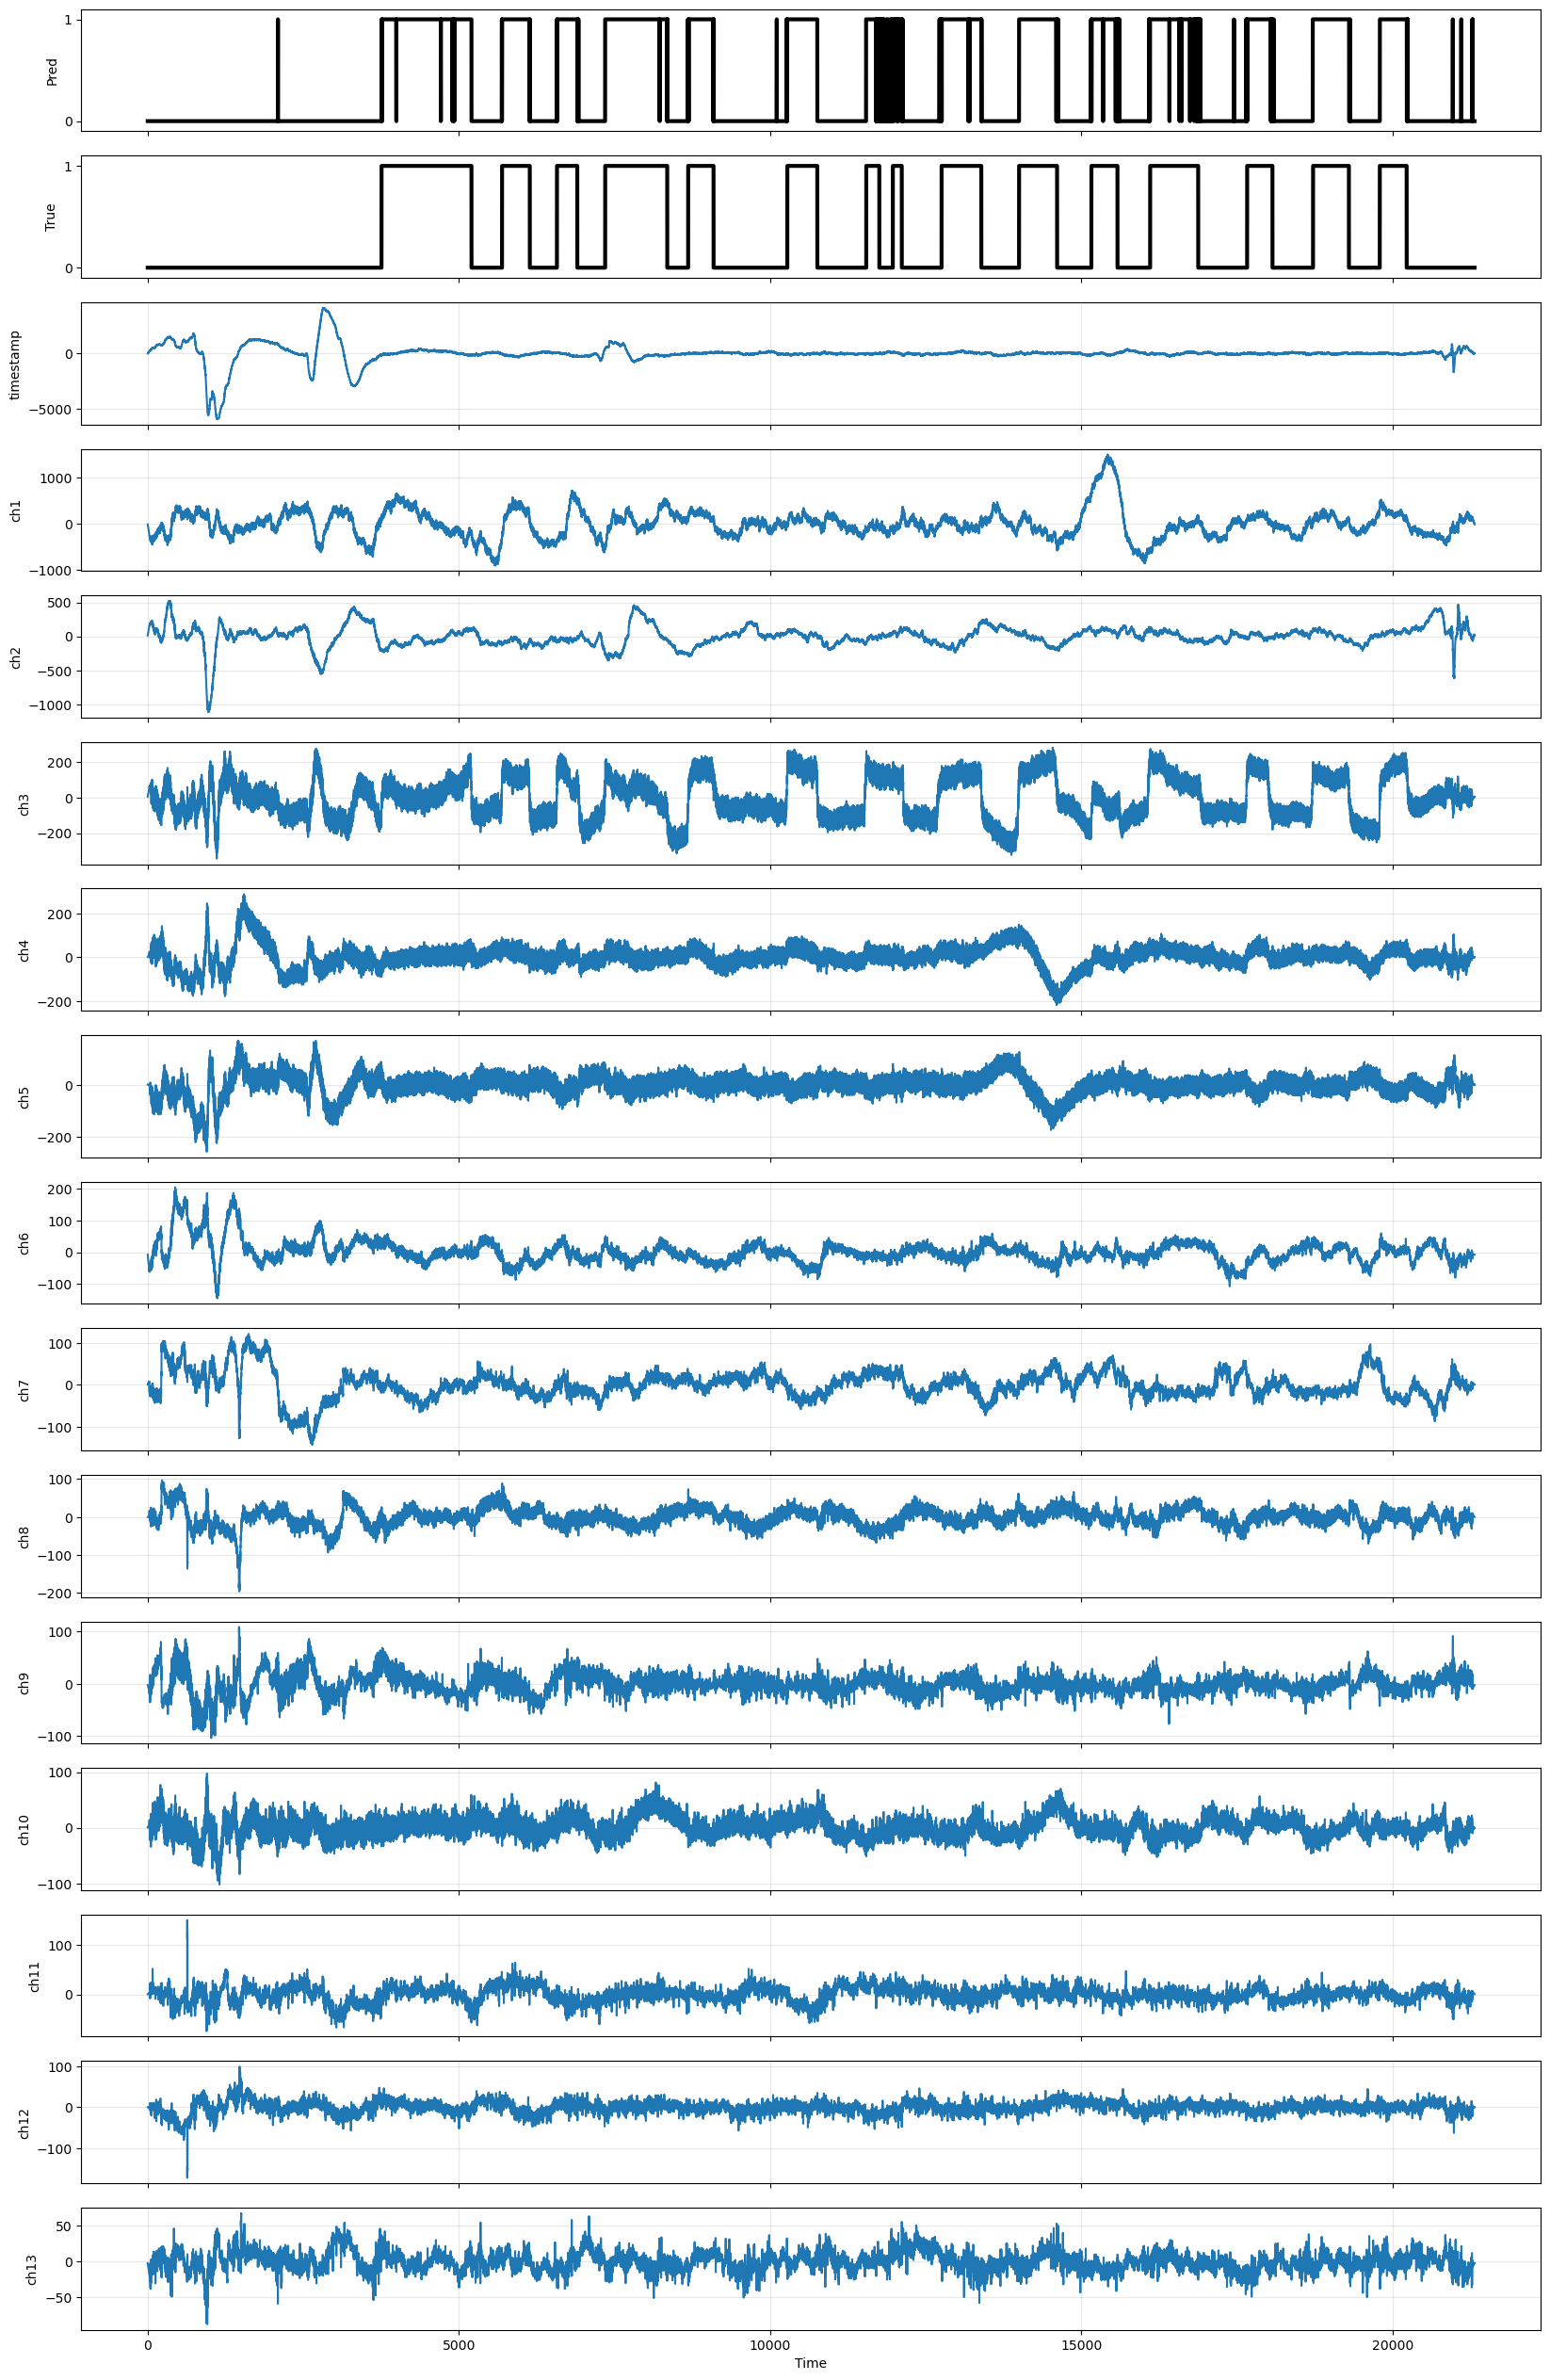

In [22]:
%matplotlib inline
signals = X_np
channels = df.columns
n_channels = signals.shape[1]
n_time = signals.shape[0]

figsize = (20, 2 * (n_channels + 2))

fig, axes = plt.subplots(n_channels + 2, 1, figsize=figsize, sharex=True)

# Predictions
axes[0].plot(all_preds, drawstyle="steps-post", linewidth=3, color="black")
axes[0].set_ylim(-0.1, 1.1)
axes[0].set_yticks([0, 1])
axes[0].set_ylabel("Pred")


# True labels
axes[1].plot(y_np, drawstyle="steps-post", linewidth=3, color="black")
axes[1].set_ylim(-0.1, 1.1)
axes[1].set_yticks([0, 1])
axes[1].set_ylabel("True")

# --- EEG signals ---
for i in range(n_channels):
    axes[i + 2].plot(signals[:, i])
    axes[i + 2].set_ylabel(channels[i])
    axes[i + 2].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time")

In [24]:
21317/250

85.268